# Advanced AGN Models: From Simple Power Laws to Unified Models

tengri provides a hierarchy of AGN SED models with increasing physical
realism. This notebook explores the advanced models: the Kubota & Done
(2018) multi-color disc with BH spin, the SKIRTOR clumpy torus, and
the unified NLR/BLR model with geometric masking. For basic models see
`04_agn_and_igm.ipynb`.

In [1]:
import os
import sys
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri.models.agn import (
    AGN_MODELS, get_agn_model, multicolor_disc, powerlaw_disc,
    two_temperature_torus, unified_nlr_blr,
)

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
if os.path.exists("data"):
    pass
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

from _plot_style import COLORS, setup_style

setup_style()
FIGDIR = os.path.join(_nb_dir, "..", "figures", "reference")
os.makedirs(FIGDIR, exist_ok=True)

wavelength = jnp.logspace(np.log10(100), np.log10(1e6), 1000)
wave_um = np.asarray(wavelength) / 1e4

## 1. Model Hierarchy Overview

| Model | Params | Disc | Torus | Best for |
|-------|--------|------|-------|----------|
| `simple` | 3 | Power-law | Single-T BB | Quick photometric fits |
| `standard` | 5-6 | Multi-color | Two-temperature | Broadband SED fitting |
| `kubota_done` | 8+ | Multi-color + spin | Two-T + optical depth | BH physics |
| `skirtor` | 7 | Power-law | SKIRTOR clumpy | Torus geometry |
| `unified_nlr_blr` | 12+ | Multi-color + spin | Two-T + NLR/BLR + masking | Type 1/2, emission lines |

In [2]:
print("Registered AGN models:")
for name, fn in AGN_MODELS.items():
    print(f"  {name:20s} -- {(fn.__doc__ or '').strip().split(chr(10))[0]}")

Registered AGN models:
  simple               -- Simple AGN: power-law disc + single-temperature torus.
  standard             -- Standard AGN: multi-color disc + two-temperature torus.
  kubota_done          -- Kubota & Done (2018) disc + clumpy torus.
  skirtor              -- SKIRTOR clumpy torus AGN: disc + SKIRTOR torus (analytic).
  unified_nlr_blr      -- Unified AGN SED with NLR/BLR decomposition and geometric masking.
  qsogen               -- QSOgen quasar SED (Temple+2021) — registered model entry point.


## 2. Kubota & Done Multi-Color Disc

BH spin $a$ sets the ISCO radius (Bardeen+1972): higher spin means
smaller ISCO, hotter inner disc, harder UV spectrum. The Eddington
ratio sets the accretion rate and temperature normalization.

KeyError: 'blue'

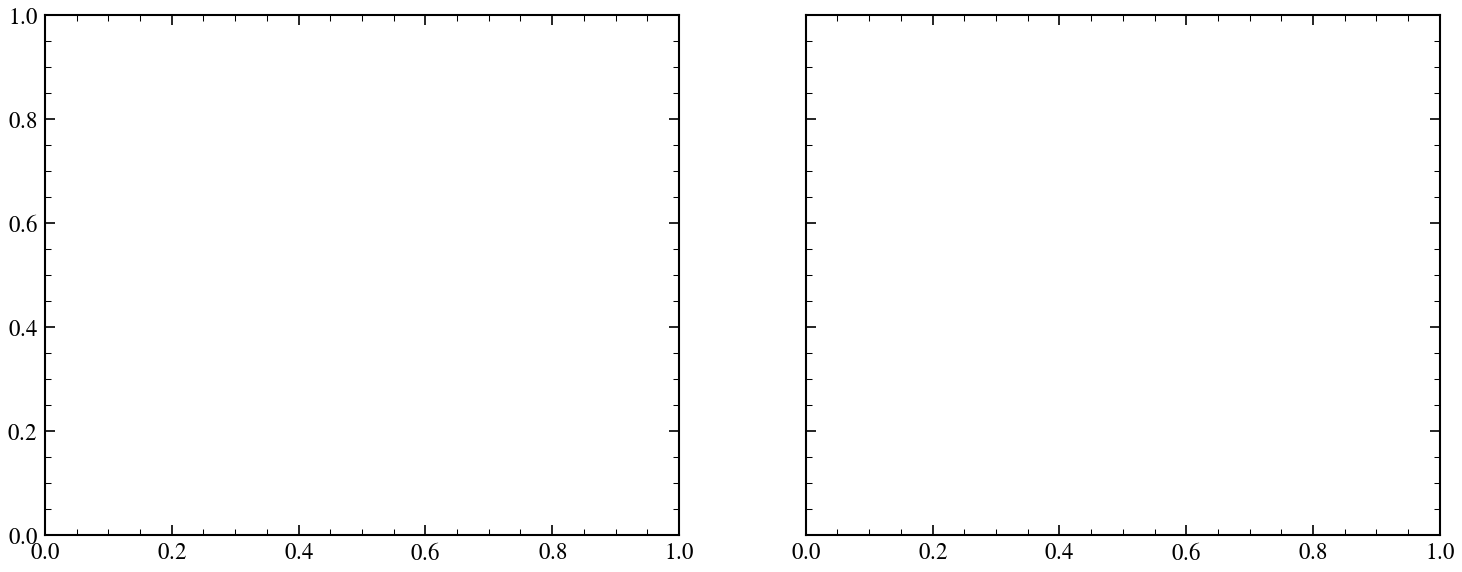

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# (a) Vary BH spin
for a, c, lb in zip([0.0, 0.5, 0.998],
                     [COLORS["blue"], COLORS["green"], COLORS["red"]],
                     ["$a=0$", "$a=0.5$", "$a=0.998$"]):
    l = multicolor_disc(wavelength, agn_log_lbol=44.0, agn_log_mbh=8.0,
                        agn_log_ledd=-1.0, agn_a_spin=a)
    axes[0].loglog(wave_um, np.asarray(l * 3e18 / wavelength), color=c, label=lb, lw=1.8)
axes[0].set(xlabel=r"Wavelength [$\mu$m]", ylabel=r"$\nu L_\nu$ [arb.]",
            title="(a) BH spin", xlim=(1e-3, 10))
axes[0].legend(fontsize=8)

# (b) Vary Eddington ratio
for le, c, lb in zip([-2.0, -1.0, -0.5],
                      [COLORS["blue"], COLORS["green"], COLORS["red"]],
                      [r"$\log\lambda=-2$", r"$\log\lambda=-1$", r"$\log\lambda=-0.5$"]):
    l = multicolor_disc(wavelength, agn_log_lbol=44.0, agn_log_mbh=8.0,
                        agn_log_ledd=le, agn_a_spin=0.0)
    axes[1].loglog(wave_um, np.asarray(l * 3e18 / wavelength), color=c, label=lb, lw=1.8)
axes[1].set(xlabel=r"Wavelength [$\mu$m]", title="(b) Eddington ratio", xlim=(1e-3, 10))
axes[1].legend(fontsize=8)
fig.suptitle("Multi-color disc (Kubota & Done 2018)", fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "11_multicolor_disc.png"), dpi=150, bbox_inches="tight")
plt.show()

W0325 13:19:28.670720 20309295 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


KeyError: 'blue'

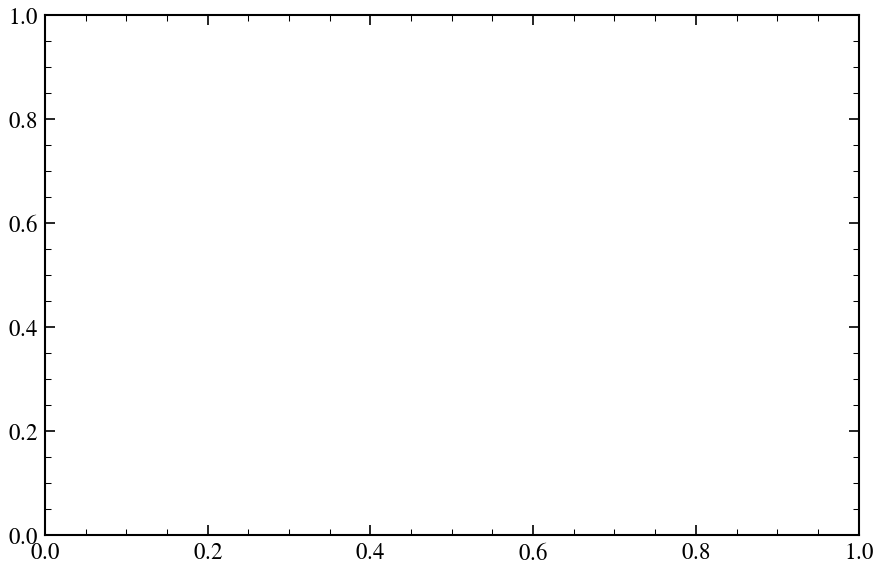

In [4]:
# Power-law vs multi-color disc comparison
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(wave_um, np.asarray(powerlaw_disc(wavelength, agn_log_lbol=44.0, agn_alpha=-1.0)),
          color=COLORS["blue"], ls="--", lw=1.8, label=r"Power-law ($\alpha=-1$)")
ax.loglog(wave_um, np.asarray(multicolor_disc(wavelength, agn_log_lbol=44.0,
          agn_log_mbh=8.0, agn_log_ledd=-1.0)),
          color=COLORS["red"], lw=1.8, label=r"Multi-color ($M_8$, $\lambda=0.1$)")
ax.set(xlabel=r"Wavelength [$\mu$m]", ylabel=r"$L_\nu$ [$L_\odot$ Hz$^{-1}$]",
       title="Power-law vs multi-color disc", xlim=(1e-3, 10))
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "11_disc_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Two-Temperature Torus

Hot ($T\sim1200$ K, sublimation) + warm ($T\sim300$ K, outer) dust,
both with silicate opacity at 9.7 $\mu$m (Stalevski+2012, 2016).

KeyError: 'blue'

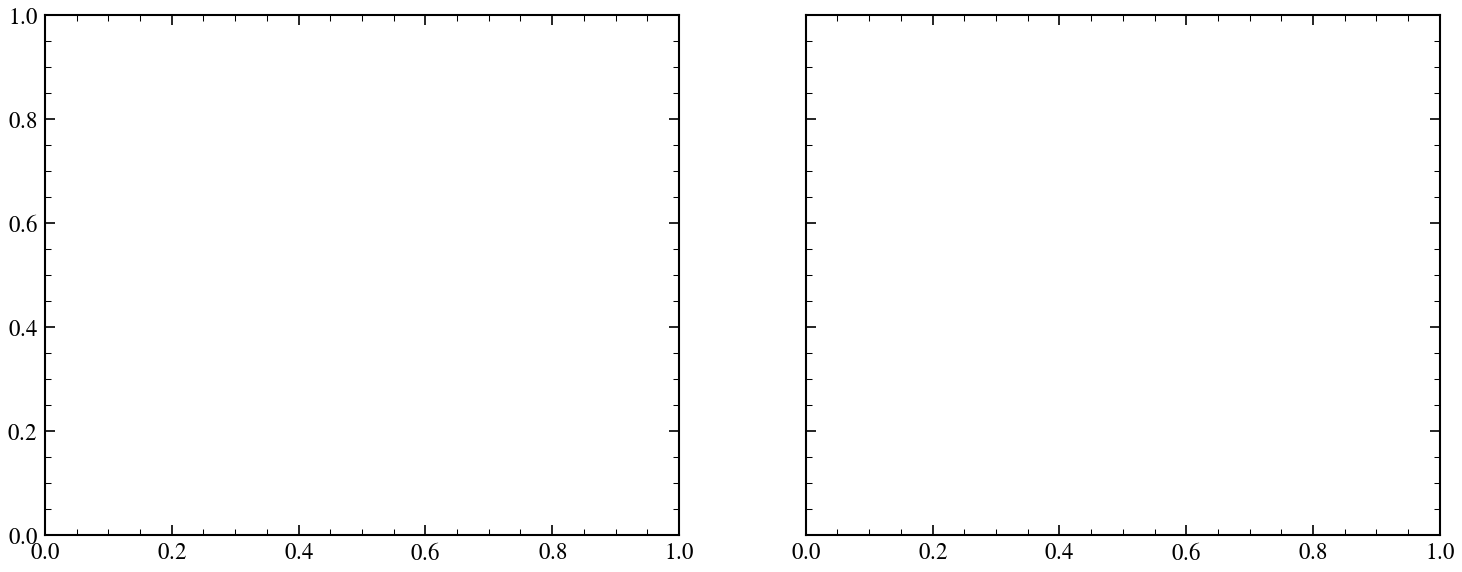

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for tau, c in zip([1.0, 5.0, 10.0], [COLORS["blue"], COLORS["green"], COLORS["red"]]):
    l = two_temperature_torus(wavelength, agn_log_lbol=44.0, agn_tau_torus=tau)
    axes[0].loglog(wave_um, np.asarray(l), color=c, label=rf"$\tau_{{9.7}}={tau:.0f}$", lw=1.8)
axes[0].axvline(9.7, color="gray", ls=":", alpha=0.5)
axes[0].set(xlabel=r"Wavelength [$\mu$m]", ylabel=r"$L_\nu$ [$L_\odot$ Hz$^{-1}$]",
            title=r"(a) Optical depth $\tau_{9.7}$", xlim=(0.5, 100))
axes[0].legend(fontsize=8)

for fh, c in zip([0.1, 0.3, 0.7], [COLORS["blue"], COLORS["green"], COLORS["red"]]):
    l = two_temperature_torus(wavelength, agn_log_lbol=44.0, agn_frac_hot=fh)
    axes[1].loglog(wave_um, np.asarray(l), color=c, label=rf"$f_{{\rm hot}}={fh}$", lw=1.8)
axes[1].axvline(9.7, color="gray", ls=":", alpha=0.5)
axes[1].set(xlabel=r"Wavelength [$\mu$m]", title="(b) Hot dust fraction", xlim=(0.5, 100))
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "11_torus_params.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. SKIRTOR Clumpy Torus

Tabulated radiative-transfer templates (Stalevski+2012, 2016). Requires
`data/skirtor_templates.npz`. Falls back to analytic torus if unavailable.

SKIRTOR unavailable ('blue'); showing two-temperature fallback.


KeyError: 'blue'

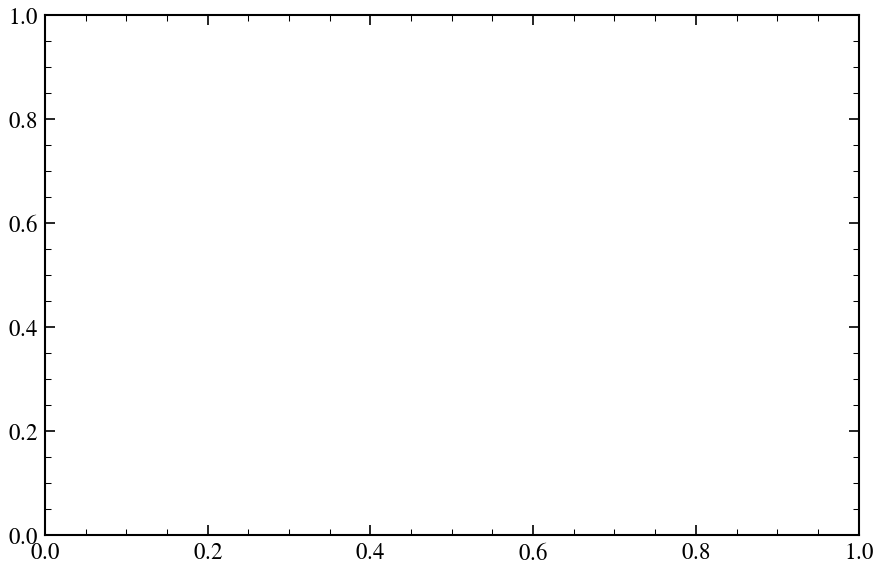

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
try:
    skirtor_fn = get_agn_model("skirtor")
    for ci, c, lb in zip([0.9, 0.5, 0.1],
                          [COLORS["blue"], COLORS["green"], COLORS["red"]],
                          [r"Face-on ($\cos i=0.9$)", r"Intermediate", r"Edge-on ($\cos i=0.1$)"]):
        l = skirtor_fn(wavelength, agn_log_lbol=44.0, agn_frac=1.0, agn_cos_inc=ci)
        ax.loglog(wave_um, np.asarray(l), color=c, label=lb, lw=1.8)
    ax.set_title("SKIRTOR: inclination dependence")
except Exception as e:
    print(f"SKIRTOR unavailable ({e}); showing two-temperature fallback.")
    for cfg, c in zip([dict(agn_frac_hot=0.5, agn_T_hot=1200.0),
                       dict(agn_frac_hot=0.3, agn_T_hot=1200.0),
                       dict(agn_frac_hot=0.1, agn_T_hot=800.0)],
                      [COLORS["blue"], COLORS["green"], COLORS["red"]]):
        l = two_temperature_torus(wavelength, agn_log_lbol=44.0, **cfg)
        ax.loglog(wave_um, np.asarray(l), color=c, lw=1.8,
                  label=f"f_hot={cfg['agn_frac_hot']}")
    ax.set_title("Two-T torus fallback")
ax.axvline(9.7, color="gray", ls=":", alpha=0.5)
ax.set(xlabel=r"Wavelength [$\mu$m]", ylabel=r"$L_\nu$ [$L_\odot$ Hz$^{-1}$]", xlim=(0.3, 200))
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "11_skirtor_torus.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Unified NLR/BLR Model: Type 1 vs Type 2

`unified_nlr_blr` adds NLR/BLR emission with sigmoid geometric masking:
- **Type 1** (face-on): disc + BLR + NLR + torus all visible
- **Type 2** (edge-on): torus blocks disc and BLR; only NLR + torus remain

KeyError: 'blue'

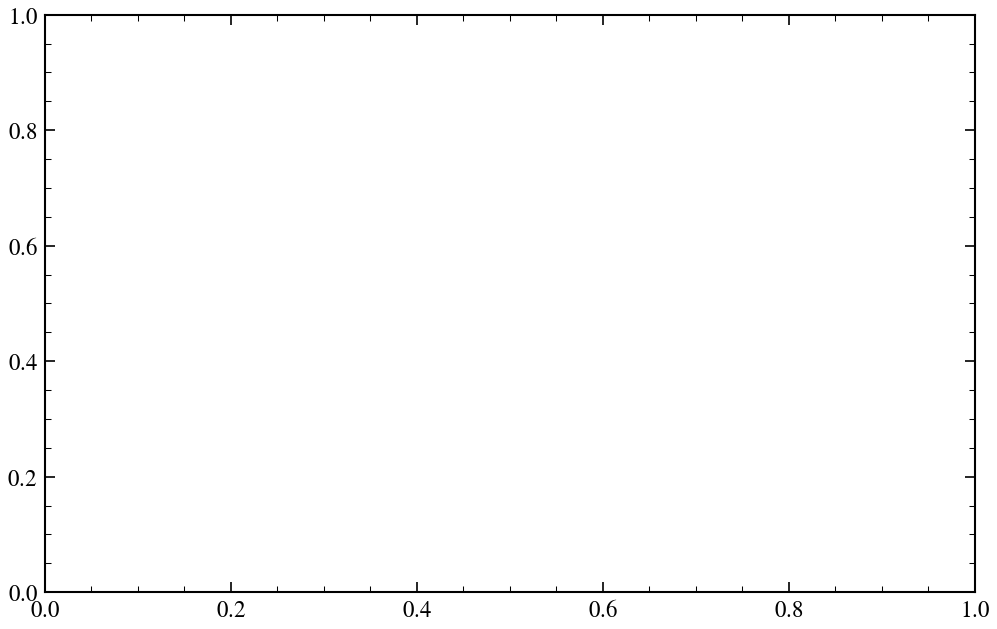

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for ci, c, lb in zip([0.95, 0.5, 0.1],
                      [COLORS["blue"], COLORS["green"], COLORS["red"]],
                      ["Type 1 (face-on)", "Intermediate", "Type 2 (edge-on)"]):
    l = unified_nlr_blr(wavelength, agn_log_lbol=44.0, agn_cos_inc=ci,
                        agn_theta_torus=30.0, agn_log_mbh=8.0, agn_frac=1.0)
    ax.loglog(wave_um, np.asarray(l * 3e18 / wavelength), color=c, label=lb, lw=1.8)
ax.axvline(0.1216, color="gray", ls=":", alpha=0.4)
ax.axvline(9.7, color="gray", ls=":", alpha=0.4)
ax.set(xlabel=r"Wavelength [$\mu$m]", ylabel=r"$\nu L_\nu$ [arb.]",
       title="Type 1 vs Type 2 from geometric masking", xlim=(1e-3, 100))
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "11_type1_vs_type2.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Full Model Comparison

KeyError: 'blue'

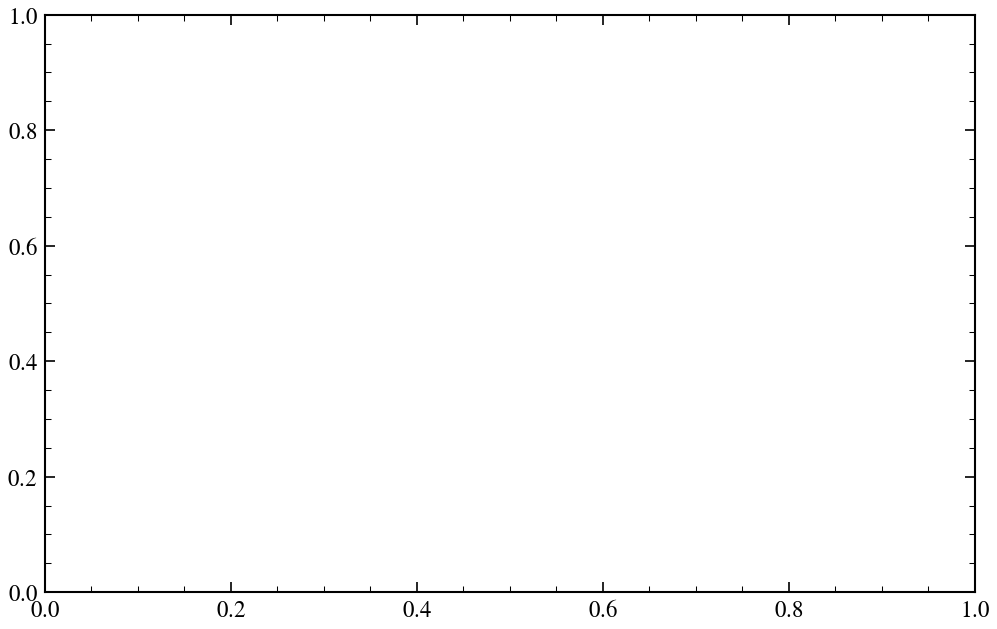

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
styles = {"simple": (COLORS["blue"], "--"), "standard": (COLORS["green"], "-"),
          "kubota_done": (COLORS["red"], "-"), "unified_nlr_blr": ("purple", "-")}
for name, (color, ls) in styles.items():
    try:
        l = get_agn_model(name)(wavelength, agn_log_lbol=44.0, agn_frac=1.0)
        ax.loglog(wave_um, np.asarray(l * 3e18 / wavelength), color=color, ls=ls,
                  label=name, lw=1.8)
    except Exception as e:
        print(f"Skipping {name}: {e}")
try:
    l = get_agn_model("skirtor")(wavelength, agn_log_lbol=44.0, agn_frac=1.0)
    ax.loglog(wave_um, np.asarray(l * 3e18 / wavelength), color="orange", ls="-.",
              label="skirtor", lw=1.8)
except Exception:
    print("SKIRTOR unavailable; omitting.")
ax.set(xlabel=r"Wavelength [$\mu$m]", ylabel=r"$\nu L_\nu$ [arb.]",
       title=r"AGN model comparison ($\log L_{\rm bol}=44$)", xlim=(1e-3, 100))
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "11_agn_model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. AGN Contribution to a Galaxy SED

KeyError: 'blue'

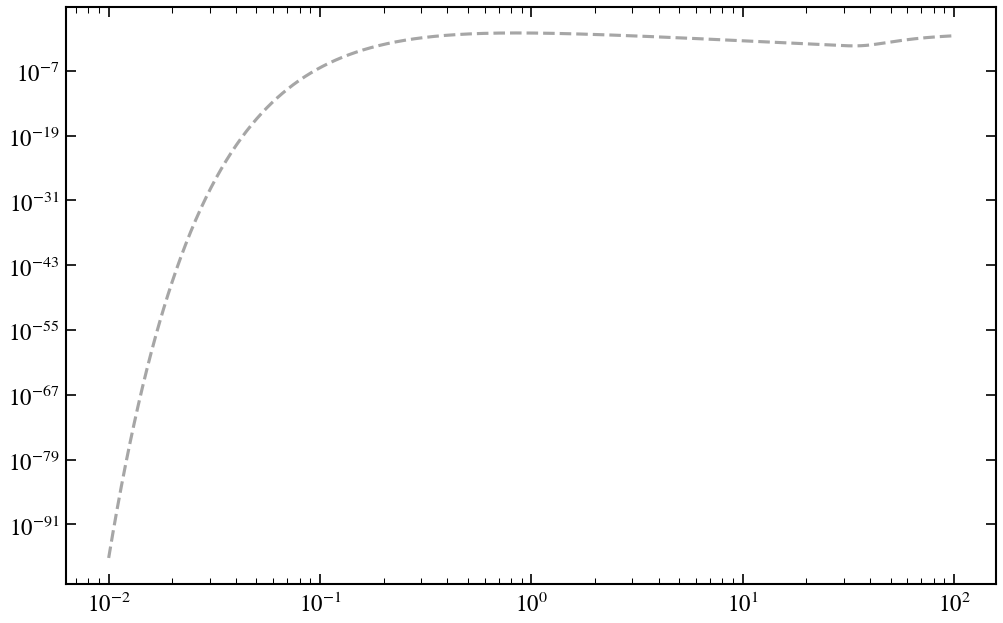

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
nu_arr = np.asarray(3e18 / wavelength)
# Schematic galaxy: stellar BB (6000 K) + dust BB (30 K)
x_s = np.clip(6.626e-27 * nu_arr / (1.381e-16 * 6000.0), 0, 500)
x_d = np.clip(6.626e-27 * nu_arr / (1.381e-16 * 30.0), 0, 500)
galaxy = nu_arr**3 / (np.exp(x_s) - 1.0)
galaxy = galaxy / galaxy.max() + 0.3 * nu_arr**3 / (np.exp(x_d) - 1.0) / (nu_arr**3 / (np.exp(x_d) - 1.0)).max()
agn_raw = np.asarray(get_agn_model("standard")(wavelength, agn_log_lbol=44.0, agn_frac=1.0))
agn_norm = agn_raw / agn_raw.max()

ax.loglog(wave_um, galaxy, color="gray", ls="--", lw=1.5, label="Host only", alpha=0.7)
for fa, c in zip([0.1, 0.3, 0.5], [COLORS["blue"], COLORS["green"], COLORS["red"]]):
    ax.loglog(wave_um, (1 - fa) * galaxy + fa * agn_norm, color=c, lw=1.8,
              label=rf"$f_{{\rm AGN}}={fa:.0%}$")
ax.set(xlabel=r"Wavelength [$\mu$m]", ylabel=r"$L_\nu$ [normalized]",
       title="Galaxy + AGN", xlim=(0.01, 100), ylim=(1e-6, 10))
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "11_galaxy_plus_agn.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Conclusion: Model Selection Guidance

- **`simple`**: Few AGN-sensitive bands; fast; minimal degeneracies.
- **`standard`**: Broadband UV-to-MIR; captures disc temperature + two-T torus.
- **`kubota_done`**: X-ray+UV+IR data; constrain $M_{\rm BH}$, spin, $\lambda_{\rm Edd}$.
- **`skirtor`**: Torus geometry science; needs tabulated templates.
- **`unified_nlr_blr`**: Spectroscopy with emission lines; Type 1/2 classification.

**Key degeneracies:** $M_{\rm BH}$/$\lambda_{\rm Edd}$ (break with spectroscopy);
spin $a$ (needs far-UV/X-ray); $\tau_{9.7}$/temperature (MIR spectroscopy);
`agn_torus_frac` (NIR constrains disc/torus split).

**See also:** [AGN & IGM](../_notebooks/reference/04_agn_and_igm) for the simple
power-law disc, simple torus, and IGM absorption (Inoue+2014).